In [ ]:
!pip install transformers

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Conv1D,  GlobalMaxPooling1D
from tensorflow.keras.layers.experimental.preprocessing import TextVectorization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from transformers import BertTokenizer, TFBertModel

import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split


In [ ]:
os.environ["WANDB_API_KEY"] = "0" ## to silence warning

In [ ]:
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.experimental.TPUStrategy(tpu)
except ValueError:
    strategy = tf.distribute.get_strategy() # for CPU and single GPU
    print('Number of replicas:', strategy.num_replicas_in_sync)

In [ ]:
# hyperparameters
max_length = 140
batch_size = 32
dev_size = 0.3

In [ ]:
# Bert Tokenizer
model_name = "bert-base-multilingual-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import pandas as pd

train_df = pd.read_csv("/content/drive/MyDrive/shashank_paper_2/merged_data.csv", header=0, names=['label', 'text'])
train_df.head()
#train_df = pd.read_excel('/content/drive/MyDrive/paper_5/Experiment with Hindi Dataset/list_hinglish.xlsx', names = ['CM', 'Hindi', 'label'])

,label,text
0,1,हमार सबसे बड़ समस्या बा कि सबकुछ के ओवरथिंक कईल
1,1,सबसे खराब उदासी उ उदासी ह जवन रउआ अपना के छिप...
2,1,हमरा त पहिलहीं से मालूम बा कि हम काफ़ी बढ़िया...
3,1,"अब हम उहे नइखीं। हम मान लेब, बहुत गंदगी हमरा ..."
4,1,"हमरा दिमाग में एतना कुछ बा, लेकिन अंत में हम ..."


In [ ]:
train_df.tail()

,label,text
12024,0,काइली जेनर अपना नवीनतम फोटो शूट में विशाल सेप...
12025,0,ट्रम्प यौन उत्पीड़न के आरोप लगावे वाला लोग प म...
12026,0,हफपोस्ट अमन सेठी के भारत के मुख्य संपादक नियु...
12027,0,लाइव देखें: संयुक्त राष्ट्र मुख्यालय में समाध...
12028,0,सेरेना विलियम्स अपना टेनिस सुपरपावर के इस्तेम...


In [ ]:
first_500 = train_df.head(500)

# Select the last 100 rows
last_500 = train_df.tail(500)

# Concatenate the first and last 100 rows
df1 = pd.concat([first_500, last_500])

In [ ]:
train, dev = train_test_split(train_df, test_size=dev_size, random_state=42)

In [ ]:
dev

,label,text
4412,0,हमरा अनुमान बा कि अभिनय के अलावा हम त बस एगो ...
10471,0,ओकलाहोमा शहर के सिपाही के गोली मार के हत्या क...
5032,0,हमरा बिजी एट वर्क जइसन अभिनय करे खातिर ऑस्कर ...
2611,1,“हमरा तब तक सुते के मन करेला जब तक कि हमरा ठी...
1562,0,अपना से प्यार करे के याद राखीं
...,...,...
1220,1,"डिप्रेशन घर जइसन लागेला, खुशी त बस एगो अइसन ज..."
9598,0,रिपोर्ट: nsa के इंटरसेप्ट कइल डेटा ज्यादातर इर...
1765,0,खुद बनीं आ रउरा कुछुओ हो सकेनी.
9927,0,4 पागल-अच्छा कबाब के रेसिपी


In [ ]:
def bert_encode(data):
    tokens = tokenizer.batch_encode_plus(data, max_length=max_length, padding='max_length', truncation=True)

    return tf.constant(tokens['input_ids'])

In [ ]:
train_encoded = bert_encode(train.text)
dev_encoded = bert_encode(dev.text)


train_dataset = (
    tf.data.Dataset
    .from_tensor_slices((train_encoded, train.label))
    .shuffle(100)
    .batch(batch_size)
)

dev_dataset = (
    tf.data.Dataset
    .from_tensor_slices((dev_encoded, dev.label))
    .shuffle(100)
    .batch(batch_size)
)

In [ ]:
def bert_tweets_model():
    # Load the BERT model
    bert_encoder = TFBertModel.from_pretrained(model_name)

    # Define input layer for BERT
    input_word_ids = tf.keras.Input(shape=(max_length,), dtype=tf.int32, name="input_ids")

    # Get BERT embeddings
    bert_output = bert_encoder(input_word_ids)[0]  # Extract BERT embeddings

    # Add multiple 1D convolutional layers with different kernel sizes
    conv1 = tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu')(bert_output)
    conv2 = tf.keras.layers.Conv1D(filters=64, kernel_size=5, activation='relu')(bert_output)
    conv3 = tf.keras.layers.Conv1D(filters=64, kernel_size=7, activation='relu')(bert_output)

    # Concatenate the output of all convolutional layers
    concat_layer = tf.keras.layers.Concatenate(axis=1)([conv1, conv2, conv3])

    # Add global max pooling layer
    pooled_layer = tf.keras.layers.GlobalMaxPooling1D()(concat_layer)

    # Add output layer
    output = tf.keras.layers.Dense(1, activation='sigmoid')(pooled_layer)

    # Define the model
    model = tf.keras.Model(inputs=input_word_ids, outputs=output)

    return model

# Initialize the model
with strategy.scope():
    model = bert_tweets_model()
    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
    model.compile(loss='binary_crossentropy', optimizer=adam_optimizer, metrics=['accuracy'])

# Print model summary
model.summary()



Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids (InputLayer)         [(None, 140)]        0           []                               
                                                                                                  
 tf_bert_model (TFBertModel)    TFBaseModelOutputWi  167356416   ['input_ids[0][0]']              
                                thPoolingAndCrossAt                                               
                                tentions(last_hidde                                               
                                n_state=(None, 140,                                               
                                 768),                                                            
                                 pooler_output=(Non                                           

In [ ]:
train_dataset

<_BatchDataset element_spec=(TensorSpec(shape=(None, 140), dtype=tf.int32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [ ]:
#from keras.utils.vis_utils import plot_model
with strategy.scope():
    model = bert_tweets_model()
    adam_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
    model.compile(loss='binary_crossentropy',optimizer=adam_optimizer,metrics=['accuracy'])

    model.summary()
    #plot_model(model=model, show_shapes=True)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids (InputLayer)         [(None, 140)]        0           []                               
                                                                                                  
 tf_bert_model_1 (TFBertModel)  TFBaseModelOutputWi  167356416   ['input_ids[0][0]']              
                                thPoolingAndCrossAt                                               
                                tentions(last_hidde                                               
                                n_state=(None, 140,                                               
                                 768),                                                            
                                 pooler_output=(Non                                         

In [ ]:
history = model.fit(
    train_dataset,
    batch_size=batch_size,
    epochs=3,
    validation_data=dev_dataset,
    verbose=2)
    #callbacks=[tf.keras.callbacks.EarlyStopping(
    #            patience=6,
    #            min_delta=0.05,
    #            baseline=0.7,
    #            mode='min',
    #            monitor='val_accuracy',
    #            restore_best_weights=True,
    #            verbose=1)
    #          ])

Epoch 1/3


264/264 - 169s - loss: 0.3766 - accuracy: 0.8189 - val_loss: 0.4571 - val_accuracy: 0.8124 - 169s/epoch - 640ms/step
Epoch 2/3
264/264 - 28s - loss: 0.2725 - accuracy: 0.8819 - val_loss: 0.2683 - val_accuracy: 0.8858 - 28s/epoch - 106ms/step
Epoch 3/3
264/264 - 28s - loss: 0.2141 - accuracy: 0.9105 - val_loss: 0.2749 - val_accuracy: 0.8833 - 28s/epoch - 104ms/step


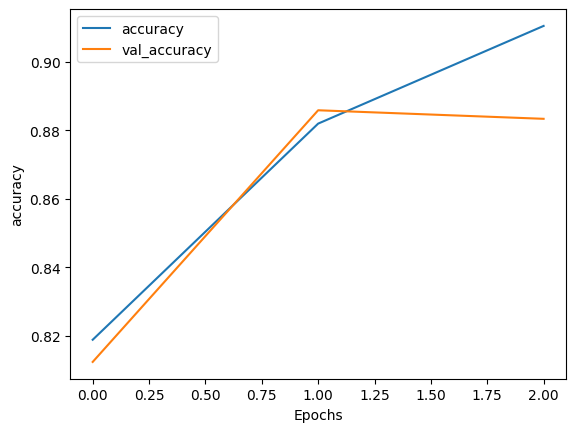

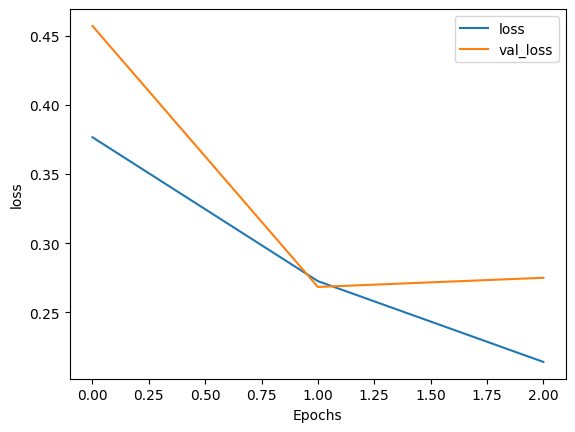

In [ ]:
import matplotlib.pyplot as plt

def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.plot(history.history['val_'+string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

In [ ]:
test, val = train_test_split(dev, test_size=dev_size, random_state=42)

In [ ]:
dev.shape

(3609, 2)

In [ ]:
test.head()

,label,text
11929,0,संभावना बा कि रैपर शिकागो के निवासी लोग के 'प...
3821,1,“कबो-कबो हमनी के उम्मीद के माध्यम से आपन दिल ...
7855,0,"टीना ठंढ, लास वेगास गोलीबारी के शिकार, कोमा स..."
11027,0,पुलिस के ऑस्टिन बमवर्षक के सेलफोन पर रिकार्ड ...
3222,1,"उ कहले कि, हमरा अकेले रहला से कवनो दिक्कत नईख..."


In [ ]:
test_encoded = bert_encode(dev.text)

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices(test_encoded)
    .batch(batch_size)
)

predicted_tweets = model.predict(test_dataset, batch_size=batch_size)
predicted_tweets_binary = tf.cast(tf.round(predicted_tweets), tf.int32).numpy().flatten()
print(predicted_tweets_binary)
#my_submission = pd.DataFrame({'id': dev.id, 'label': predicted_tweets_binary})
#my_submission.to_csv('my_submission.csv', index=False)

113/113 [==============================] - 15s 71ms/step
[0 0 0 ... 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn import metrics


In [ ]:
print("Bert+LSTM")
print("Accuracy score =", accuracy_score(dev['label'], predicted_tweets_binary))
print(metrics.classification_report(dev['label'], predicted_tweets_binary))


Bert+LSTM
Accuracy score = 0.883347187586589
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      2171
           1       0.89      0.80      0.85      1438

    accuracy                           0.88      3609
   macro avg       0.89      0.87      0.88      3609
weighted avg       0.88      0.88      0.88      3609



In [1]:
pip install googletrans==4.0.0-rc1


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 966.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 7.0 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-4.0.0rc1-py3-none-any.whl size=17395 sha256=b9dda5c7d731d1db9a5918559908e066da86d6d4c4f107427ae3df41866f3668
  Stored in directory: /root/.cache/pip/wheels/c0/59/9f/7372f0cf70160fe61b528532e1a7c8498c4becd6bcffb022de
Successfully built googletrans
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling

In [5]:
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv('/content/drive/MyDrive/shashank_paper_1/data_final.csv')

# Write the DataFrame to an Excel file
df.to_excel('output.xlsx', index=False)


In [1]:
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv('/content/drive/MyDrive/shashank_paper_2/Bhojpuri/merged_data.csv')

In [2]:
df.head()

,label,text
0,1,हमार सबसे बड़ समस्या बा कि सबकुछ के ओवरथिंक कईल
1,1,सबसे खराब उदासी उ उदासी ह जवन रउआ अपना के छिप...
2,1,हमरा त पहिलहीं से मालूम बा कि हम काफ़ी बढ़िया...
3,1,"अब हम उहे नइखीं। हम मान लेब, बहुत गंदगी हमरा ..."
4,1,"हमरा दिमाग में एतना कुछ बा, लेकिन अंत में हम ..."


In [3]:
pip install transformers

In [4]:
pip install tensorflow

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
import tensorflow as tf
from transformers import BertTokenizer, TFBertForSequenceClassification

# Load pre-trained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')
model = TFBertForSequenceClassification.from_pretrained('bert-base-multilingual-cased')

# Function to preprocess text and predict label
def predict_label(text):
    inputs = tokenizer(text, return_tensors='tf', padding=True, truncation=True, max_length=512)
    outputs = model(inputs)[0]
    predicted_label = tf.argmax(outputs, axis=1).numpy()
    return predicted_label

# Function to read CSV file and make predictions
def predict_from_csv(file_path):
    df = pd.read_csv(file_path)
    true_labels = df['label'].tolist()
    predicted_labels = []
    for index, row in df.iterrows():
        text = row['text']
        predicted_label = predict_label(text)
        predicted_labels.append(predicted_label)
    return true_labels, predicted_labels

# Example usage
file_path = '/content/drive/MyDrive/shashank_paper_2/Bhojpuri/merged_data.csv'
true_labels, predicted_labels = predict_from_csv(file_path)
print(classification_report(true_labels, predicted_labels))


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
